# **FNAARCNN: Fake News Detection Using an Attention-Augmented Residual Convolutional Neural Network**

# Download Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("bhavikjikadara/fake-news-detection")

Using Colab cache for faster access to the 'fake-news-detection' dataset.


# Import libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import string
import os
import warnings
warnings.filterwarnings("ignore")

# Load dataset

In [ ]:
import os
import pandas as pd

print("Dataset path:", path)
print("Files in path:", os.listdir(path))


fake_df = pd.read_csv(os.path.join(path, "fake.csv"))
true_df = pd.read_csv(os.path.join(path, "true.csv"))

fake_df["label"] = "Fake"
true_df["label"] = "Real"


df = pd.concat([fake_df, true_df], ignore_index=True)



Dataset path: /kaggle/input/fake-news-detection
Files in path: ['true.csv', 'fake.csv']


# Read dataset

In [ ]:
df

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",Real
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",Real
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",Real
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",Real


In [ ]:
df[["text", "label"]]



,text,label
0,Donald Trump just couldn t wish all Americans ...,Fake
1,House Intelligence Committee Chairman Devin Nu...,Fake
2,"On Friday, it was revealed that former Milwauk...",Fake
3,"On Christmas day, Donald Trump announced that ...",Fake
4,Pope Francis used his annual Christmas Day mes...,Fake
...,...,...
44893,BRUSSELS (Reuters) - NATO allies on Tuesday we...,Real
44894,"LONDON (Reuters) - LexisNexis, a provider of l...",Real
44895,MINSK (Reuters) - In the shadow of disused Sov...,Real
44896,MOSCOW (Reuters) - Vatican Secretary of State ...,Real


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


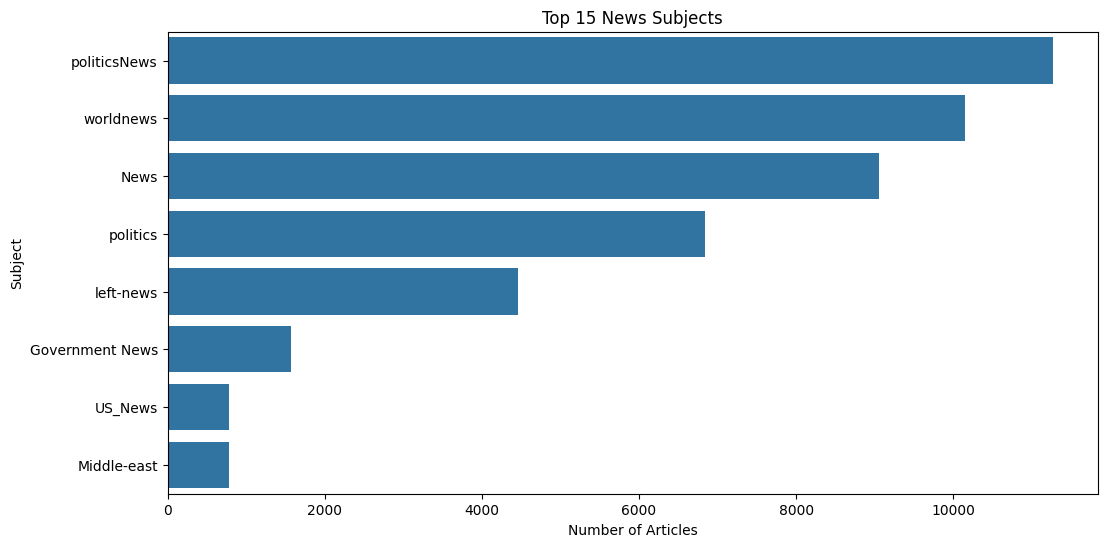

In [ ]:
subject_counts = df["subject"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(y=subject_counts.index, x=subject_counts.values)
plt.title("Top 15 News Subjects")
plt.xlabel("Number of Articles")
plt.ylabel("Subject")
plt.show()


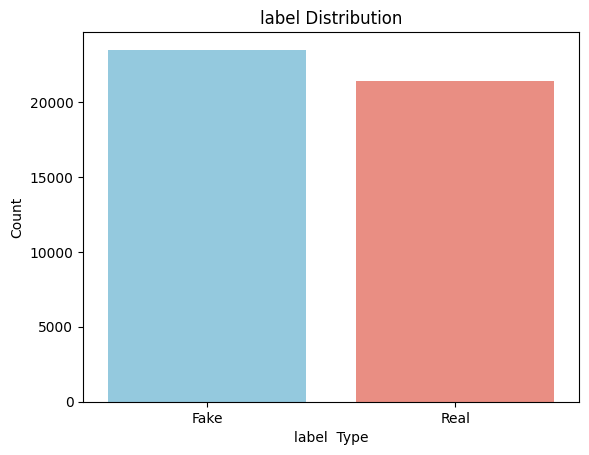

In [ ]:
sns.countplot(
    x="label",
    data=df,
    palette=["skyblue", "salmon"]
)

plt.title("label Distribution")
plt.xlabel("label  Type")
plt.ylabel("Count")
plt.show()

# Data Preprocessing

In [ ]:
import string
import nltk
import numpy as np
import pandas as pd

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


nltk.download("stopwords")

stop_words = set(stopwords.words("english"))


def clean_text(text):
    text = str(text).lower()
    text = "".join(ch for ch in text if ch not in string.punctuation)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)


df = df[["text", "label"]]
df.dropna(inplace=True)

df["text"] = df["text"].apply(clean_text)


label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))


tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df["text"]).toarray()
y = df["label"].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_train = np.array(X_train, dtype=np.float32)
X_test  = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_test  = np.array(y_test, dtype=np.float32)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("y_train dtype:", y_train.dtype)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


{'Fake': np.int64(0), 'Real': np.int64(1)}
X_train shape: (35918, 5000, 1)
y_train dtype: float32


# Build model

# Attention Augmented Residual Convolutional Neural Network (AARCNN)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


def build_AARCNN_model(input_shape):
    model = Sequential([
        Conv1D(128, kernel_size=5, activation="relu", input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(64, kernel_size=3, activation="relu"),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_AARCNN_model(input_shape=(X_train.shape[1], 1))


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)



# Train model

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 867s 963ms/step - accuracy: 0.9020 - loss: 0.2200 - val_accuracy: 0.9854 - val_loss: 0.0461
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 858s 956ms/step - accuracy: 0.9913 - loss: 0.0261 - val_accuracy: 0.9910 - val_loss: 0.0244
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 813s 905ms/step - accuracy: 0.9970 - loss: 0.0088 - val_accuracy: 0.9926 - val_loss: 0.0269
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 896s 943ms/step - accuracy: 0.9983 - loss: 0.0056 - val_accuracy: 0.9939 - val_loss: 0.0268
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 819s 896ms/step - accuracy: 0.9976 - loss: 0.0068 - val_accuracy: 0.9940 - val_loss: 0.0251


# model history

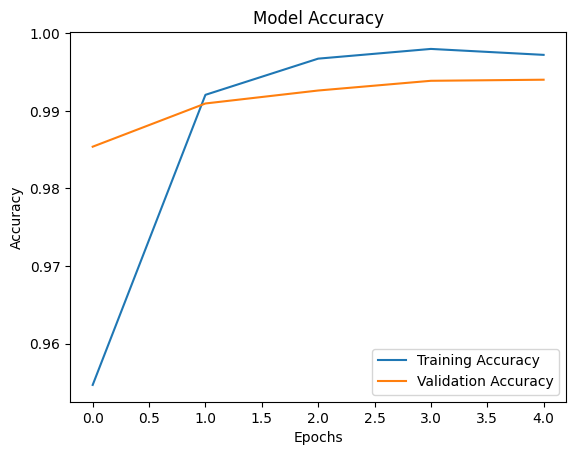

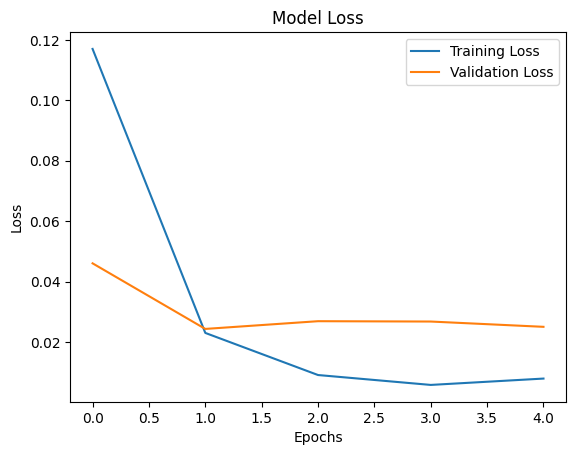

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()


plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()


# Save Model

In [ ]:
import joblib
model.save("aarcnn_fake_news_model.keras")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")


['label_encoder.pkl']

# Confusion Matrix

281/281 ━━━━━━━━━━━━━━━━━━━━ 53s 190ms/step


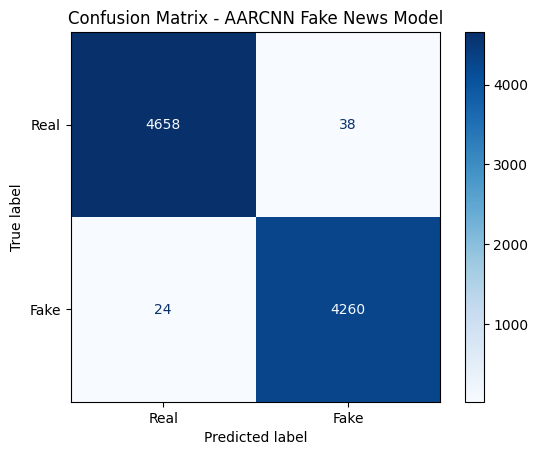

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred_probs = model.predict(X_test)


y_pred = (y_pred_probs > 0.5).astype(int)


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - AARCNN Fake News Model")
plt.show()


# Performance Metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)



accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
error_rate = 1 - accuracy


roc_auc = roc_auc_score(y_test, y_pred_probs)

print("Performance Metrics")
print("-" * 20)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"Error Rate  : {error_rate:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")




Performance Metrics
--------------------
Accuracy    : 0.9931
Precision   : 0.9912
Recall      : 0.9944
F1 Score    : 0.9928
Error Rate  : 0.0069
ROC-AUC     : 0.9997


# prediction

In [ ]:
import string
import numpy as np
import joblib
import nltk
from nltk.corpus import stopwords
import tensorflow as tf

# -------------------------------------------------
# 1. Load saved model and objects
# -------------------------------------------------
model = tf.keras.models.load_model("aarcnn_fake_news_model.keras")
tfidf = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# -------------------------------------------------
# 2. Text cleaning (same as training)
# -------------------------------------------------
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = "".join(ch for ch in text if ch not in string.punctuation)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# -------------------------------------------------
# 3. Prediction function (LABEL ONLY)
# -------------------------------------------------
def predict_fake_news(text):
    cleaned_text = clean_text(text)

    X = tfidf.transform([cleaned_text]).toarray().astype(np.float32)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    prob = model.predict(X, verbose=0)[0][0]
    label = int(prob > 0.5)

    return label_encoder.inverse_transform([label])[0]

# -------------------------------------------------
# 4. Example usage
# -------------------------------------------------
sample_text = """
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year!  Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you  Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress.  Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me?  Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish??  Marlene (@marlene399) December 31, 2017You can t just say happy new year?  Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love!  Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his  enemies  and  haters  for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA  Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President?  Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down.  Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters?  Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old  Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images.
"""

prediction = predict_fake_news(sample_text)
print("Prediction:", prediction)
